In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import BayesianRidge

In [2]:
X = np.linspace(0,1,50).reshape(-1,1)
y = 2.5*X.squeeze() + np.random.normal(0,0.2,size= 50)


In [3]:
model = BayesianRidge()
model.fit(X,y)

BayesianRidge()

In [4]:
y_mean,y_std = model.predict(X,return_std=True)

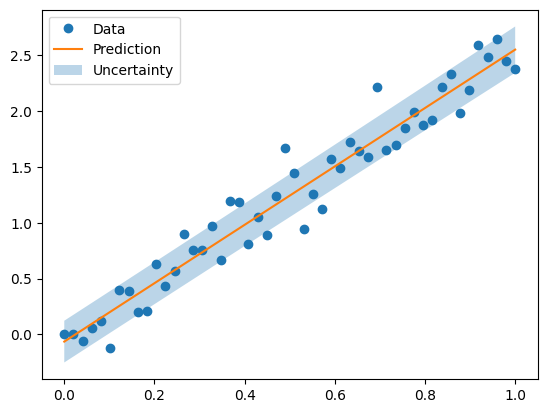

In [5]:
plt.plot(X, y, 'o', label="Data")
plt.plot(X, y_mean, label="Prediction")
plt.fill_between(X.ravel(), y_mean - y_std, y_mean + y_std, alpha=0.3, label="Uncertainty")
plt.legend()
plt.show()



---

# 📘 **Bayesian Linear Regression: Full Theory & Math**

---

## 1. ✅ **Problem Setup: Linear Regression**

We are modeling a dataset:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N
$$

with a **linear model**:

$$
y_i = \mathbf{w}^\top \mathbf{x}_i + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

### 🔸 Matrix Form:

Let:

* $\mathbf{X} \in \mathbb{R}^{N \times d}$ be input matrix
* $\mathbf{w} \in \mathbb{R}^{d}$ is weight vector
* $\mathbf{y} \in \mathbb{R}^{N}$ is output vector

Then:

$$
\mathbf{y} = \mathbf{Xw} + \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(0, \sigma^2 \mathbf{I})
$$

---

## 2. 🧠 **Bayesian Viewpoint**

### 🎯 Objective:

Find **posterior distribution** of weights:

$$
p(\mathbf{w} \mid \mathbf{X}, \mathbf{y})
$$

Using **Bayes' Theorem**:

$$
p(\mathbf{w} \mid \mathbf{X}, \mathbf{y}) = \frac{p(\mathbf{y} \mid \mathbf{X}, \mathbf{w}) p(\mathbf{w})}{p(\mathbf{y} \mid \mathbf{X})}
$$

---

## 3. 🧮 **Step-by-Step Derivations**

---

### **A. Prior on Weights**

Assume:

$$
\mathbf{w} \sim \mathcal{N}(0, \tau^2 \mathbf{I})
$$

This means: we expect small weights (regularization).

---

### **B. Likelihood**

Given weights $\mathbf{w}$, the likelihood of $\mathbf{y}$ is:

$$
p(\mathbf{y} \mid \mathbf{X}, \mathbf{w}) = \mathcal{N}(\mathbf{Xw}, \sigma^2 \mathbf{I})
$$

---

### **C. Posterior Derivation**

The **posterior** is also Gaussian:

$$
p(\mathbf{w} \mid \mathbf{X}, \mathbf{y}) = \mathcal{N}(\mathbf{w}_N, \mathbf{S}_N)
$$

Where:

#### 🔹 Posterior Covariance:

$$
\mathbf{S}_N = \left(\frac{1}{\sigma^2} \mathbf{X}^\top \mathbf{X} + \frac{1}{\tau^2} \mathbf{I} \right)^{-1}
$$

#### 🔹 Posterior Mean:

$$
\mathbf{w}_N = \frac{1}{\sigma^2} \mathbf{S}_N \mathbf{X}^\top \mathbf{y}
$$

👉 This is **Bayesian equivalent** to **ridge regression**, where the prior acts like L2 regularization.

---

## 4. 📈 **Prediction with Uncertainty**

We want to predict $y_*$ for new $\mathbf{x}_*$:

$$
p(y_* \mid \mathbf{x}_*, \mathbf{X}, \mathbf{y}) = \int p(y_* \mid \mathbf{x}_*, \mathbf{w}) p(\mathbf{w} \mid \mathbf{X}, \mathbf{y}) \, d\mathbf{w}
$$

This integral gives a **Gaussian** again:

$$
p(y_* \mid \mathbf{x}_*, \mathbf{X}, \mathbf{y}) = \mathcal{N}(\mu_*, \sigma_*^2)
$$

Where:

### 🔸 Predictive Mean:

$$
\mu_* = \mathbf{x}_*^\top \mathbf{w}_N
$$

### 🔸 Predictive Variance:

$$
\sigma_*^2 = \mathbf{x}_*^\top \mathbf{S}_N \mathbf{x}_* + \sigma^2
$$

👉 The uncertainty comes from **two sources**:

* Variability in $\mathbf{w}$ (model uncertainty)
* Noise $\sigma^2$ (data noise)

---

## 5. 📚 Comparison with Frequentist Linear Regression

| Aspect          | Frequentist               | Bayesian                   |
| --------------- | ------------------------- | -------------------------- |
| Output          | Point estimate of weights | Distribution over weights  |
| Regularization  | Optional (ridge, lasso)   | Comes naturally from prior |
| Prediction      | Mean only                 | Mean + uncertainty         |
| Prior knowledge | Not used                  | Explicitly encoded         |

---

## 6. 📐 Example Summary of Equations

| Quantity       | Formula                                                                                          |
| -------------- | ------------------------------------------------------------------------------------------------ |
| Prior          | $\mathbf{w} \sim \mathcal{N}(0, \tau^2 \mathbf{I})$                                              |
| Likelihood     | $p(\mathbf{y} \mid \mathbf{w}) = \mathcal{N}(\mathbf{Xw}, \sigma^2 \mathbf{I})$                  |
| Posterior      | $\mathbf{w} \mid \mathbf{y} \sim \mathcal{N}(\mathbf{w}_N, \mathbf{S}_N)$                        |
| Predictive     | $y_* \sim \mathcal{N}(\mu_*, \sigma_*^2)$                                                        |
| $\mathbf{w}_N$ | $\frac{1}{\sigma^2} \mathbf{S}_N \mathbf{X}^\top \mathbf{y}$                                     |
| $\mathbf{S}_N$ | $\left(\frac{1}{\sigma^2} \mathbf{X}^\top \mathbf{X} + \frac{1}{\tau^2} \mathbf{I} \right)^{-1}$ |

---

## 7. 🧪 Related Concepts

| Term                | Meaning                                        |
| ------------------- | ---------------------------------------------- |
| **MAP estimate**    | Maximum of posterior (like ridge)              |
| **MLE**             | Ignores prior; maximizes likelihood only       |
| **Bayesian Ridge**  | scikit-learn approximation of posterior        |
| **Conjugate prior** | Prior that makes posterior closed-form         |
| **Sampling**        | If posterior is complex, use MCMC (e.g. PyMC3) |

---

## 8. 🔗 Further Reading & Resources

* [📘 Bishop: Pattern Recognition and Machine Learning – Chapter 3](https://www.microsoft.com/en-us/research/publication/pattern-recognition-machine-learning/)
* [🔍 PyMC3 docs (Bayesian modeling)](https://docs.pymc.io/)
* [🧮 Arviz for Bayesian diagnostics](https://python.arviz.org/)
* [📦 scikit-learn: Bayesian Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.BayesianRidge.html)

---


